# BeyondSmile: A Challenge on Detecting Depression through Facial Behavior and Head Gestures


In [36]:
import pandas as pd
import numpy as np
import tsfel
import neurokit2 as nk
import matplotlib.pyplot as plt
import datetime
import json
import pycatch22


# Reorder the data

In [37]:
with open('./dataset/data/P08.json', 'r') as f:
        data = json.load(f)

In [38]:
type(data)

list

In [39]:
times = []
numbers = []
for i in range(0, len(data)):
    times.append(int(data[i]['timestamp'])/1000)
    numbers.append(i)
min_value = datetime.datetime.fromtimestamp(min(times)).isoformat()
max_value = datetime.datetime.fromtimestamp(max(times)).isoformat()

In [40]:
times

[1659525355.627,
 1659191227.843,
 1660448441.255,
 1660388502.855,
 1658655742.723,
 1660496440.263,
 1658391187.594,
 1658572465.164,
 1660403007.57,
 1659290482.065,
 1658900517.775,
 1660293897.11,
 1658462496.328,
 1658462493.708,
 1658505245.307,
 1658774353.445,
 1659801264.426,
 1659278020.362,
 1658389413.287,
 1660281705.224,
 1660367578.693,
 1660370172.546,
 1660283042.544,
 1660466131.023,
 1660465584.011,
 1660448557.536,
 1658921246.931,
 1660448675.708,
 1660095202.088,
 1660291940.266,
 1658390079.043,
 1658816189.343,
 1658776557.694,
 1658849378.234,
 1660099587.746,
 1658824599.027,
 1660462160.376,
 1658816921.806,
 1658942694.495,
 1659709915.625,
 1660096739.801,
 1658952813.059,
 1659290041.133,
 1660096779.347,
 1658817021.47,
 1658921228.313,
 1660104907.98,
 1660552666.311,
 1658828083.613,
 1660107111.076,
 1660284188.293,
 1660624537.429,
 1660149959.687,
 1658496102.801,
 1658814922.791,
 1658480498.718,
 1659971669.223,
 1660151260.316,
 1658773591.719,
 

In [41]:
b = enumerate(times)
c = sorted(b, key = lambda i:i[1])
times_index_primary = []

for e in c:
    times_index_primary.append(e[0])

sorted_times = sorted(times)
    
#print(times_index_primary)
print(sorted(times))

[1658378789.636, 1658378790.577, 1658378791.474, 1658378792.45, 1658378793.336, 1658378794.252, 1658378795.148, 1658378796.007, 1658378887.358, 1658378888.21, 1658378889.983, 1658378890.797, 1658378891.701, 1658378892.606, 1658378907.582, 1658378908.463, 1658378909.274, 1658378910.193, 1658378911.091, 1658378911.999, 1658378912.89, 1658378913.586, 1658378914.308, 1658378925.482, 1658378926.171, 1658378926.834, 1658378927.515, 1658378928.174, 1658379015.565, 1658379016.361, 1658379017.191, 1658379018.08, 1658379018.792, 1658379019.408, 1658379020.024, 1658379020.73, 1658379021.458, 1658379022.182, 1658379102.477, 1658379103.348, 1658379104.254, 1658379105.139, 1658379106.026, 1658379106.858, 1658379107.746, 1658379108.652, 1658379109.563, 1658379110.489, 1658379111.353, 1658379112.286, 1658379113.196, 1658379114.066, 1658379114.979, 1658379115.893, 1658379116.79, 1658379117.665, 1658379118.513, 1658379119.387, 1658379120.312, 1658379121.203, 1658379122.102, 1658379122.982, 1658379123.91

In [42]:
sorted_times_iso = []
for i in range(0, len(sorted_times)):
    sorted_times_iso.append(datetime.datetime.fromtimestamp(sorted_times[i]).isoformat())

In [43]:
sorted_times_iso

['2022-07-21T06:46:29.636000',
 '2022-07-21T06:46:30.577000',
 '2022-07-21T06:46:31.474000',
 '2022-07-21T06:46:32.450000',
 '2022-07-21T06:46:33.336000',
 '2022-07-21T06:46:34.252000',
 '2022-07-21T06:46:35.148000',
 '2022-07-21T06:46:36.007000',
 '2022-07-21T06:48:07.358000',
 '2022-07-21T06:48:08.210000',
 '2022-07-21T06:48:09.983000',
 '2022-07-21T06:48:10.797000',
 '2022-07-21T06:48:11.701000',
 '2022-07-21T06:48:12.606000',
 '2022-07-21T06:48:27.582000',
 '2022-07-21T06:48:28.463000',
 '2022-07-21T06:48:29.274000',
 '2022-07-21T06:48:30.193000',
 '2022-07-21T06:48:31.091000',
 '2022-07-21T06:48:31.999000',
 '2022-07-21T06:48:32.890000',
 '2022-07-21T06:48:33.586000',
 '2022-07-21T06:48:34.308000',
 '2022-07-21T06:48:45.482000',
 '2022-07-21T06:48:46.171000',
 '2022-07-21T06:48:46.834000',
 '2022-07-21T06:48:47.515000',
 '2022-07-21T06:48:48.174000',
 '2022-07-21T06:50:15.565000',
 '2022-07-21T06:50:16.361000',
 '2022-07-21T06:50:17.191000',
 '2022-07-21T06:50:18.080000',
 '2022-0

# Reorder data json

In [44]:
data2 = []
for i in range(0, len(times_index_primary)):
    data2.append(data[times_index_primary[i]])

In [45]:
times = []
numbers = []
for i in range(0, len(data2)):
    times.append(int(data2[i]['timestamp'])/1000)
    numbers.append(i)

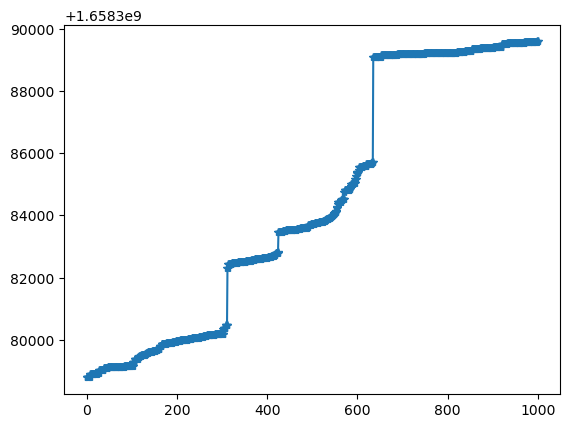

In [46]:
plt.plot(numbers[0:1000], times[0:1000], '-*')

# Read the labels

In [47]:
data_phq = pd.read_csv('./dataset/groundtruth/phq9.csv')

In [48]:
data_phq

,pid,start_ts,end_ts,start_phq9,end_phq9,depression_episode
0,P08,7/21/22,8/9/22,6,1.0,0
1,P08,8/9/22,8/23/22,1,9.0,0
2,P10,7/21/22,8/9/22,8,7.0,1
3,P10,8/9/22,9/2/22,7,2.0,0
4,P12,7/22/22,8/9/22,10,12.0,1
5,P12,8/9/22,8/23/22,12,9.0,1
6,P13,7/25/22,8/9/22,1,3.0,0
7,P13,8/9/22,8/23/22,3,2.0,0
8,P14,7/25/22,8/8/22 0:00,11,NaN,0
9,P15,7/26/22,8/10/22,4,9.0,0


In [49]:
data_patient_depression = data_phq.loc[0]

In [50]:
data_patient_depression


pid                       P08
start_ts              7/21/22
end_ts                 8/9/22
start_phq9                  6
end_phq9                  1.0
depression_episode          0
Name: 0, dtype: object

In [51]:
start_monitoring = data_patient_depression.start_ts
end_monitoring = data_patient_depression.end_ts

In [52]:
#Change the dates into the timestamp

In [53]:
element_start = datetime.datetime(int(start_monitoring.split('/')[2])+2000, int(start_monitoring.split('/')[0]), int(start_monitoring.split('/')[1]))

In [54]:
element_start

datetime.datetime(2022, 7, 21, 0, 0)

In [55]:
timestamp_start = datetime.datetime.timestamp(element_start)
element_end = datetime.datetime(int(end_monitoring.split('/')[2])+2000, int(end_monitoring.split('/')[0]), int(end_monitoring.split('/')[1]))
timestamp_end = datetime.datetime.timestamp(element_end)


# Find the beginning of the record and end of the record

In [56]:
counter_start = 0
while(sorted_times[counter_start]<timestamp_start):
    counter_start +=1

In [57]:
counter_end = counter_start
while(sorted_times[counter_end]<=timestamp_end):
    counter_end +=1
counter_end = counter_end - 1

In [58]:
counter_end

29612

In [59]:
sorted_times[counter_end]

1659981485.896

In [60]:
datetime.datetime.fromtimestamp(sorted_times[counter_end])

datetime.datetime(2022, 8, 8, 19, 58, 5, 896000)

In [61]:
#Select subdataset
data3 = data2[counter_start:counter_end+1]

In [62]:
datetime.datetime.fromtimestamp(float(data3[0]['timestamp'])/1000).hour

6

# Select the day for 4 periods: midnight (12am-6am), morning (6am-12pm), afternoon (12pm-6pm), and evening (6pm12am) (to daytime!)

In [63]:
midnight_time = []
morning_time = []
afternoon_time = []
evening_time = []
for i in range(0, len(data3)):
    hour_sample = datetime.datetime.fromtimestamp(float(data3[i]['timestamp'])/1000).hour
    if hour_sample>=0 and hour_sample<6:
        midnight_time.append(i)
    if hour_sample>=6 and hour_sample<12:
        morning_time.append(i)
    if hour_sample>=12 and hour_sample<18:
        afternoon_time.append(i)
    if hour_sample>=18 and hour_sample<=23:
        evening_time.append(i)
        

In [64]:
for i in range(0, len(evening_time)):
    print(datetime.datetime.fromtimestamp(float(data3[evening_time[i]]['timestamp'])/1000))

2022-07-22 18:13:59.945000
2022-07-22 18:14:10.549000
2022-07-22 18:14:11.755000
2022-07-22 18:14:14.187000
2022-07-22 18:18:30.709000
2022-07-25 18:14:12.453000
2022-07-25 18:14:12.947000
2022-07-25 18:14:13.382000
2022-07-25 18:14:13.813000
2022-07-25 18:14:14.317000
2022-07-25 18:14:14.811000
2022-07-25 18:14:15.294000
2022-07-25 18:14:15.727000
2022-07-25 18:14:16.174000
2022-07-25 18:14:16.596000
2022-07-25 18:14:30.726000
2022-07-25 18:14:31.333000
2022-07-25 18:14:31.825000
2022-07-25 18:14:32.223000
2022-07-25 18:14:32.653000
2022-07-25 18:14:33.104000
2022-07-25 18:14:33.564000
2022-07-25 18:14:34.042000
2022-07-25 18:14:34.489000
2022-07-25 18:14:34.913000
2022-07-25 18:14:35.404000
2022-07-25 18:14:35.866000
2022-07-25 18:14:36.274000
2022-07-25 18:14:36.720000
2022-07-25 18:14:40.053000
2022-07-25 18:14:40.868000
2022-07-25 18:14:41.237000
2022-07-25 18:14:41.700000
2022-07-25 18:14:42.208000
2022-07-25 18:14:42.708000
2022-07-25 18:14:43.239000
2022-07-25 18:14:43.733000
2

In [65]:
data_midnight = []
for i in range(0, len(midnight_time)):
    data_midnight.append(data3[midnight_time[i]])

In [66]:
data_morning = []
for i in range(0, len(morning_time)):
    data_morning.append(data3[morning_time[i]])

In [67]:
len(data_morning)

14197

In [68]:
data_afternoon = []
for i in range(0, len(afternoon_time)):
    data_afternoon.append(data3[afternoon_time[i]])

In [69]:
len(data_afternoon)

9960

In [70]:
data_evening = []
for i in range(0, len(evening_time)):
    data_evening.append(data3[evening_time[i]])

# Define separete subdata for the midningt, morning, afternoon and evening 

# Extract midnight featues for smiling and open eyes probabilities

In [71]:
COLUMN_NAMES = ['X', 'Y', 'Z']
COLUMN_NAMES_mid = []
for i in range(0, len(COLUMN_NAMES)):
    COLUMN_NAMES_mid.append(COLUMN_NAMES[i] +'_mid')
records_euler_mid = pd.DataFrame(columns= COLUMN_NAMES_mid)

for i in range(0, len(data_midnight)):
    euler_data = data_midnight[i]['headEulerAngle']
    euler_values = list(euler_data.values())

    if len(euler_data)!=0:
        records_euler_mid.loc[i] = euler_values
    else: 
        records_euler_mid.loc[i] = [np.nan]*3

In [72]:
records_euler_mid

,X_mid,Y_mid,Z_mid
0,-12.861740,-9.943131,-5.549485
1,-8.195009,-11.667619,5.466350
2,-8.315527,10.084205,12.250936
3,-15.607402,0.981894,11.403200
4,-16.872519,4.333885,3.137351
...,...,...,...
202,-7.974183,-3.702225,-10.527580
203,-7.298408,-3.857266,-10.489188
204,-7.946996,-4.713626,-9.841791
205,-5.101610,-3.150212,-7.772576


In [73]:
records_euler_mid_cleaned = records_euler_mid.copy()
records_euler_mid_cleaned = records_euler_mid_cleaned.dropna()

In [74]:
records_euler_mid_cleaned

,X_mid,Y_mid,Z_mid
0,-12.861740,-9.943131,-5.549485
1,-8.195009,-11.667619,5.466350
2,-8.315527,10.084205,12.250936
3,-15.607402,0.981894,11.403200
4,-16.872519,4.333885,3.137351
...,...,...,...
202,-7.974183,-3.702225,-10.527580
203,-7.298408,-3.857266,-10.489188
204,-7.946996,-4.713626,-9.841791
205,-5.101610,-3.150212,-7.772576


In [75]:
# Retrieves a pre-defined feature configuration file to extract the temporal, statistical and spectral feature sets
cfg = tsfel.get_features_by_domain()

# Extract features
X = tsfel.time_series_features_extractor(cfg, records_euler_mid_cleaned)

C:\Users\skiju\AppData\Local\Temp\ipykernel_9732\535113824.py:5: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, records_euler_mid_cleaned)


In [76]:
#Delete spectograms-related features
X_mid_to_delete = []
for name in X.columns:
    if 'Spectrogram mean coefficient_' in name:
        X_mid_to_delete.append(name)

In [77]:
X = X.drop(X_mid_to_delete, axis=1)


In [78]:
X

,X_mid_Absolute energy,X_mid_Area under the curve,X_mid_Autocorrelation,X_mid_Average power,X_mid_Centroid,X_mid_ECDF Percentile Count_0,X_mid_ECDF Percentile Count_1,X_mid_ECDF Percentile_0,X_mid_ECDF Percentile_1,X_mid_ECDF_0,...,Z_mid_Wavelet variance_12.5Hz,Z_mid_Wavelet variance_2.78Hz,Z_mid_Wavelet variance_25.0Hz,Z_mid_Wavelet variance_3.12Hz,Z_mid_Wavelet variance_3.57Hz,Z_mid_Wavelet variance_4.17Hz,Z_mid_Wavelet variance_5.0Hz,Z_mid_Wavelet variance_6.25Hz,Z_mid_Wavelet variance_8.33Hz,Z_mid_Zero crossing rate
0,23855.220164,17.3408,16.0,11580.203963,0.936651,41.0,165.0,-9.678244,8.12968,0.004831,...,34.762451,89.60866,14.642857,84.146945,86.242983,92.821844,96.461769,88.68106,63.958353,24.0


In [79]:
data_euler_mid = X.copy()

In [80]:
for j in range(0, len(COLUMN_NAMES_mid)):
    name_euler = COLUMN_NAMES_mid[j]
    features_pycatch = pycatch22.catch22_all(records_euler_mid_cleaned[name_euler])
    COLUMN = []
    for i in range(0, len(features_pycatch['names'])):
        COLUMN.append(name_euler+ '_' + features_pycatch['names'][i]) 
    features_euler_sub_mid = pd.DataFrame(columns=COLUMN)
    features_euler_sub_mid.loc[0] = features_pycatch['values']
    if j == 0:
        features_euler_mid = features_euler_sub_mid.copy()
    else:
        features_euler_mid = pd.concat([features_euler_mid, features_euler_sub_mid], axis=1)
            
        

In [81]:
features_euler_mid

,X_mid_DN_HistogramMode_5,X_mid_DN_HistogramMode_10,X_mid_CO_f1ecac,X_mid_CO_FirstMin_ac,X_mid_CO_HistogramAMI_even_2_5,X_mid_CO_trev_1_num,X_mid_MD_hrv_classic_pnn40,X_mid_SB_BinaryStats_mean_longstretch1,X_mid_SB_TransitionMatrix_3ac_sumdiagcov,X_mid_PD_PeriodicityWang_th0_01,...,Z_mid_FC_LocalSimple_mean1_tauresrat,Z_mid_DN_OutlierInclude_p_001_mdrmd,Z_mid_DN_OutlierInclude_n_001_mdrmd,Z_mid_SP_Summaries_welch_rect_area_5_1,Z_mid_SB_BinaryStats_diff_longstretch0,Z_mid_SB_MotifThree_quantile_hh,Z_mid_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_mid_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_mid_SP_Summaries_welch_rect_centroid,Z_mid_FC_LocalSimple_mean3_stderr
0,-0.00831,-0.306163,14.248871,8.0,0.516409,-0.123251,0.81068,56.0,0.0625,24.0,...,0.037037,-0.149758,-0.024155,0.63753,5.0,1.999853,0.142857,0.857143,0.392699,0.861177


In [82]:
data_euler_mid = pd.concat([data_euler_mid, features_euler_mid], axis=1)

In [83]:
data_euler_mid

,X_mid_Absolute energy,X_mid_Area under the curve,X_mid_Autocorrelation,X_mid_Average power,X_mid_Centroid,X_mid_ECDF Percentile Count_0,X_mid_ECDF Percentile Count_1,X_mid_ECDF Percentile_0,X_mid_ECDF Percentile_1,X_mid_ECDF_0,...,Z_mid_FC_LocalSimple_mean1_tauresrat,Z_mid_DN_OutlierInclude_p_001_mdrmd,Z_mid_DN_OutlierInclude_n_001_mdrmd,Z_mid_SP_Summaries_welch_rect_area_5_1,Z_mid_SB_BinaryStats_diff_longstretch0,Z_mid_SB_MotifThree_quantile_hh,Z_mid_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_mid_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_mid_SP_Summaries_welch_rect_centroid,Z_mid_FC_LocalSimple_mean3_stderr
0,23855.220164,17.3408,16.0,11580.203963,0.936651,41.0,165.0,-9.678244,8.12968,0.004831,...,0.037037,-0.149758,-0.024155,0.63753,5.0,1.999853,0.142857,0.857143,0.392699,0.861177


In [84]:
approx_entropy_columns = [name + '_app_ent' for name in records_euler_mid_cleaned.columns]
data_approx_entropy_mid = pd.DataFrame(columns=approx_entropy_columns)
app_ent_euler_mid= []



In [85]:
for i in range(0, len(approx_entropy_columns)): 
    try:
        approximate_entropy, parameters = nk.entropy_approximate(records_euler_mid_cleaned[records_euler_mid_cleaned.columns[i]])
         # Approximate entropy
    except:
        approximate_entropy = 0
    app_ent_euler_mid.append(approximate_entropy)
data_approx_entropy_mid.loc[0] = app_ent_euler_mid

In [86]:
data_approx_entropy_mid

,X_mid_app_ent,Y_mid_app_ent,Z_mid_app_ent
0,0.714327,0.790807,0.893495


In [87]:
data_euler_mid = pd.concat([data_euler_mid, data_approx_entropy_mid], axis=1)

In [88]:
rsd_columns_mid = [name + '_rsd' for name in records_euler_mid_cleaned.columns]
data_rsd_mid = pd.DataFrame(columns=rsd_columns_mid)
rsd_euler_mid = []
for i in range(0, len(rsd_columns_mid)): 
    rsd = 100*np.std(records_euler_mid_cleaned[records_euler_mid_cleaned.columns[i]])/(np.mean(records_euler_mid_cleaned[records_euler_mid_cleaned.columns[i]])+0.00000000000000000000001)
    rsd_euler_mid.append(rsd)
data_rsd_mid.loc[0] = rsd_euler_mid


In [89]:
data_euler_mid = pd.concat([data_euler_mid, data_rsd_mid], axis=1)

In [90]:
data_euler_mid

,X_mid_Absolute energy,X_mid_Area under the curve,X_mid_Autocorrelation,X_mid_Average power,X_mid_Centroid,X_mid_ECDF Percentile Count_0,X_mid_ECDF Percentile Count_1,X_mid_ECDF Percentile_0,X_mid_ECDF Percentile_1,X_mid_ECDF_0,...,Z_mid_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_mid_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_mid_SP_Summaries_welch_rect_centroid,Z_mid_FC_LocalSimple_mean3_stderr,X_mid_app_ent,Y_mid_app_ent,Z_mid_app_ent,X_mid_rsd,Y_mid_rsd,Z_mid_rsd
0,23855.220164,17.3408,16.0,11580.203963,0.936651,41.0,165.0,-9.678244,8.12968,0.004831,...,0.142857,0.857143,0.392699,0.861177,0.714327,0.790807,0.893495,-6931.976855,-833.12303,-101.722603


# For morning

In [91]:
COLUMN_NAMES = ['X', 'Y', 'Z']
COLUMN_NAMES_mor = []
for i in range(0, len(COLUMN_NAMES)):
    COLUMN_NAMES_mor.append(COLUMN_NAMES[i] +'_mor')
records_euler_mor = pd.DataFrame(columns= COLUMN_NAMES_mor)

for i in range(0, len(data_morning)):
    euler_data = data_morning[i]['headEulerAngle']
    euler_values = list(euler_data.values())

    if len(euler_data)!=0:
        records_euler_mor.loc[i] = euler_values
    else: 
        records_euler_mor.loc[i] = [np.nan]*3

In [92]:
records_euler_mor_cleaned = records_euler_mor.copy()
records_euler_mor_cleaned = records_euler_mor_cleaned.dropna()

In [93]:
# Retrieves a pre-defined feature configuration file to extract the temporal, statistical and spectral feature sets
cfg = tsfel.get_features_by_domain()

# Extract features
X = tsfel.time_series_features_extractor(cfg, records_euler_mor_cleaned)

C:\Users\skiju\AppData\Local\Temp\ipykernel_9732\2237436862.py:5: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, records_euler_mor_cleaned)


In [94]:
#Delete spectograms-related features
X_mor_to_delete = []
for name in X.columns:
    if 'Spectrogram mean coefficient_' in name:
        X_mor_to_delete.append(name)

In [95]:
X = X.drop(X_mor_to_delete, axis=1)

In [96]:
data_euler_mor = X.copy()

In [97]:
for j in range(0, len(COLUMN_NAMES_mor)):
    name_euler = COLUMN_NAMES_mor[j]
    features_pycatch = pycatch22.catch22_all(records_euler_mor_cleaned[name_euler])
    COLUMN = []
    for i in range(0, len(features_pycatch['names'])):
        COLUMN.append(name_euler+ '_' + features_pycatch['names'][i]) 
    features_euler_sub_mor = pd.DataFrame(columns=COLUMN)
    features_euler_sub_mor.loc[0] = features_pycatch['values']
    if j == 0:
        features_euler_mor = features_euler_sub_mor.copy()
    else:
        features_euler_mor = pd.concat([features_euler_mor, features_euler_sub_mor], axis=1)
            
        

In [98]:
data_euler_mor = pd.concat([data_euler_mor, features_euler_mor], axis=1)

In [99]:
approx_entropy_columns = [name + '_app_ent' for name in records_euler_mor_cleaned.columns]
data_approx_entropy_mor = pd.DataFrame(columns=approx_entropy_columns)
app_ent_euler_mor= []



In [100]:
for i in range(0, len(approx_entropy_columns)): 
    try:
        approximate_entropy, parameters = nk.entropy_approximate(records_euler_mor_cleaned[records_euler_mor_cleaned.columns[i]])
         # Approximate entropy
    except:
        approximate_entropy = 0
    app_ent_euler_mor.append(approximate_entropy)
data_approx_entropy_mor.loc[0] = app_ent_euler_mor

In [101]:
data_euler_mor = pd.concat([data_euler_mor, data_approx_entropy_mor], axis=1)

In [102]:
rsd_columns_mor= [name + '_rsd' for name in records_euler_mor_cleaned.columns]
data_rsd_mor = pd.DataFrame(columns=rsd_columns_mor)
rsd_euler_mor = []
for i in range(0, len(rsd_columns_mor)): 
    rsd = 100*np.std(records_euler_mor_cleaned[records_euler_mor_cleaned.columns[i]])/(np.mean(records_euler_mor_cleaned[records_euler_mor_cleaned.columns[i]])+0.00000000000000000000001)
    rsd_euler_mor.append(rsd)
data_rsd_mor.loc[0] = rsd_euler_mor


In [103]:
data_euler_mor = pd.concat([data_euler_mor, data_rsd_mor], axis=1)

In [104]:
data_euler_mor

,X_mor_Absolute energy,X_mor_Area under the curve,X_mor_Autocorrelation,X_mor_Average power,X_mor_Centroid,X_mor_ECDF Percentile Count_0,X_mor_ECDF Percentile Count_1,X_mor_ECDF Percentile_0,X_mor_ECDF Percentile_1,X_mor_ECDF_0,...,Z_mor_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_mor_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_mor_SP_Summaries_welch_rect_centroid,Z_mor_FC_LocalSimple_mean3_stderr,X_mor_app_ent,Y_mor_app_ent,Z_mor_app_ent,X_mor_rsd,Y_mor_rsd,Z_mor_rsd
0,1.020274e+06,951.877955,40.0,7187.054308,67.178453,2839.0,11357.0,-9.643051,1.774329,0.00007,...,0.28,0.8,0.067495,0.5763,1.114497,1.231507,1.138405,-201.124128,537.152616,-108.009918


# Afternoon data for smiling and eyes probabilities

In [105]:
COLUMN_NAMES = ['X', 'Y', 'Z']
COLUMN_NAMES_aft = []
for i in range(0, len(COLUMN_NAMES)):
    COLUMN_NAMES_aft.append(COLUMN_NAMES[i] +'_aft')
records_euler_aft = pd.DataFrame(columns= COLUMN_NAMES_aft)

for i in range(0, len(data_afternoon)):
    euler_data = data_afternoon[i]['headEulerAngle']
    euler_values = list(euler_data.values())

    if len(euler_data)!=0:
        records_euler_aft.loc[i] = euler_values
    else: 
        records_euler_aft.loc[i] = [np.nan]*3

In [106]:
records_euler_aft_cleaned = records_euler_aft.copy()
records_euler_aft_cleaned = records_euler_aft_cleaned.dropna()

In [107]:
# Retrieves a pre-defined feature configuration file to extract the temporal, statistical and spectral feature sets
cfg = tsfel.get_features_by_domain()

# Extract features
X = tsfel.time_series_features_extractor(cfg, records_euler_aft_cleaned)

C:\Users\skiju\AppData\Local\Temp\ipykernel_9732\2537382359.py:5: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, records_euler_aft_cleaned)


In [108]:
#Delete spectograms-related features
X_aft_to_delete = []
for name in X.columns:
    if 'Spectrogram mean coefficient_' in name:
        X_aft_to_delete.append(name)

In [109]:
X = X.drop(X_aft_to_delete, axis=1)

In [110]:
data_euler_aft = X.copy()

In [111]:
for j in range(0, len(COLUMN_NAMES_aft)):
    name_euler = COLUMN_NAMES_aft[j]
    features_pycatch = pycatch22.catch22_all(records_euler_aft_cleaned[name_euler])
    COLUMN = []
    for i in range(0, len(features_pycatch['names'])):
        COLUMN.append(name_euler+ '_' + features_pycatch['names'][i]) 
    features_euler_sub_aft = pd.DataFrame(columns=COLUMN)
    features_euler_sub_aft.loc[0] = features_pycatch['values']
    if j == 0:
        features_euler_aft = features_euler_sub_aft.copy()
    else:
        features_euler_aft = pd.concat([features_euler_aft, features_euler_sub_aft], axis=1)
            
        

In [112]:
data_euler_aft = pd.concat([data_euler_aft, features_euler_aft], axis=1)

In [113]:
approx_entropy_columns = [name + '_app_ent' for name in records_euler_aft_cleaned.columns]
data_approx_entropy_aft = pd.DataFrame(columns=approx_entropy_columns)
app_ent_euler_aft= []



In [114]:
for i in range(0, len(approx_entropy_columns)): 
    try:
        approximate_entropy, parameters = nk.entropy_approximate(records_euler_aft_cleaned[records_euler_aft_cleaned.columns[i]])
         # Approximate entropy
    except:
        approximate_entropy = 0
    app_ent_euler_aft.append(approximate_entropy)
data_approx_entropy_aft.loc[0] = app_ent_euler_aft

In [115]:
data_approx_entropy_aft

,X_aft_app_ent,Y_aft_app_ent,Z_aft_app_ent
0,1.11791,1.234068,1.198197


In [116]:
data_euler_aft = pd.concat([data_euler_aft, data_approx_entropy_aft], axis=1)

In [117]:
rsd_columns_aft= [name + '_aft' for name in records_euler_aft_cleaned.columns]
data_rsd_aft = pd.DataFrame(columns=rsd_columns_aft)
rsd_euler_aft = []
for i in range(0, len(rsd_columns_aft)): 
    rsd = 100*np.std(records_euler_aft_cleaned[records_euler_aft_cleaned.columns[i]])/(np.mean(records_euler_aft_cleaned[records_euler_aft_cleaned.columns[i]])+0.00000000000000000000001)
    rsd_euler_aft.append(rsd)
data_rsd_aft.loc[0] = rsd_euler_aft


In [118]:
data_euler_aft = pd.concat([data_euler_aft, data_rsd_aft], axis=1)

In [119]:
data_euler_aft

,X_aft_Absolute energy,X_aft_Area under the curve,X_aft_Autocorrelation,X_aft_Average power,X_aft_Centroid,X_aft_ECDF Percentile Count_0,X_aft_ECDF Percentile Count_1,X_aft_ECDF Percentile_0,X_aft_ECDF Percentile_1,X_aft_ECDF_0,...,Z_aft_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,Z_aft_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,Z_aft_SP_Summaries_welch_rect_centroid,Z_aft_FC_LocalSimple_mean3_stderr,X_aft_app_ent,Y_aft_app_ent,Z_aft_app_ent,X_aft_aft,Y_aft_aft,Z_aft_aft
0,665792.644907,646.889458,38.0,6685.336328,51.595202,1992.0,7968.0,-9.099035,2.513267,0.0001,...,0.54,0.5,0.068646,0.601799,1.11791,1.234068,1.198197,-269.065889,453.418186,-119.857495


# Probabilities for evening

In [120]:
COLUMN_NAMES = ['X', 'Y', 'Z']
COLUMN_NAMES_eve = []
for i in range(0, len(COLUMN_NAMES)):
    COLUMN_NAMES_eve.append(COLUMN_NAMES[i] +'_eve')
records_euler_eve = pd.DataFrame(columns= COLUMN_NAMES_eve)

for i in range(0, len(data_evening)):
    euler_data = data_evening[i]['headEulerAngle']
    euler_values = list(euler_data.values())

    if len(euler_data)!=0:
        records_euler_eve.loc[i] = euler_values
    else: 
        records_euler_eve.loc[i] = [np.nan]*3

In [121]:
records_euler_eve_cleaned = records_euler_eve.copy()
records_euler_eve_cleaned = records_euler_eve_cleaned.dropna()

In [122]:
# Retrieves a pre-defined feature configuration file to extract the temporal, statistical and spectral feature sets
cfg = tsfel.get_features_by_domain()

# Extract features
X = tsfel.time_series_features_extractor(cfg, records_euler_eve_cleaned)

C:\Users\skiju\AppData\Local\Temp\ipykernel_9732\2555404120.py:5: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, records_euler_eve_cleaned)


In [123]:
#Delete spectograms-related features
X_eve_to_delete = []
for name in X.columns:
    if 'Spectrogram mean coefficient_' in name:
        X_eve_to_delete.append(name)

In [124]:
X = X.drop(X_eve_to_delete, axis=1)

In [125]:
data_euler_eve = X.copy()

In [126]:
for j in range(0, len(COLUMN_NAMES_eve)):
    name_euler = COLUMN_NAMES_eve[j]
    features_pycatch = pycatch22.catch22_all(records_euler_eve_cleaned[name_euler])
    COLUMN = []
    for i in range(0, len(features_pycatch['names'])):
        COLUMN.append(name_euler+ '_' + features_pycatch['names'][i]) 
    features_euler_sub_eve = pd.DataFrame(columns=COLUMN)
    features_euler_sub_eve.loc[0] = features_pycatch['values']
    if j == 0:
        features_euler_eve = features_euler_sub_eve.copy()
    else:
        features_euler_eve = pd.concat([features_euler_eve, features_euler_sub_eve], axis=1)
            
        

In [127]:
data_euler_eve = pd.concat([data_euler_eve, features_euler_eve], axis=1)

In [128]:
approx_entropy_columns = [name + '_app_ent' for name in records_euler_eve_cleaned.columns]
data_approx_entropy_eve = pd.DataFrame(columns=approx_entropy_columns)
app_ent_euler_eve= []



In [129]:
for i in range(0, len(approx_entropy_columns)): 
    try:
        approximate_entropy, parameters = nk.entropy_approximate(records_euler_eve_cleaned[records_euler_eve_cleaned.columns[i]])
         # Approximate entropy
    except:
        approximate_entropy = 0
    app_ent_euler_eve.append(approximate_entropy)
data_approx_entropy_eve.loc[0] = app_ent_euler_eve
data_approx_entropy_eve

,X_eve_app_ent,Y_eve_app_ent,Z_eve_app_ent
0,1.240145,1.414059,1.101619


In [130]:
data_euler_eve = pd.concat([data_euler_eve, data_approx_entropy_eve], axis=1)

In [131]:
rsd_columns_eve= [name + '_rsd' for name in records_euler_eve_cleaned.columns]
data_rsd_eve = pd.DataFrame(columns=rsd_columns_eve)
rsd_euler_eve = []
for i in range(0, len(rsd_columns_eve)): 
    rsd = 100*np.std(records_euler_eve_cleaned[records_euler_eve_cleaned.columns[i]])/(np.mean(records_euler_eve_cleaned[records_euler_eve_cleaned.columns[i]])+0.00000000000000000000001)
    rsd_euler_eve.append(rsd)
data_rsd_eve.loc[0] = rsd_euler_eve


In [132]:
data_euler_eve = pd.concat([data_euler_eve, data_rsd_eve], axis=1)

# Concat all probabilites

In [133]:
data_euler = pd.concat([data_euler_mid, data_euler_mor, data_euler_aft, data_euler_eve], axis=1)